#Tarea 3

##Leonardo Garcia Muñoz


In [1]:
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
#Usaremos el mismo dataset que en clase para no batallar

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv", encoding="latin-1")
df = df[["v1", "v2"]].copy()
df.columns = ["label", "text"]

stop_words = ENGLISH_STOP_WORDS

def clean_text(text: str) -> str:
    r = re.sub(r"[^a-zA-Z]", " ", str(text))
    r = r.lower().split()
    r = [w for w in r if w not in stop_words and len(w) > 1]
    return " ".join(r)

df["text_clean"] = df["text"].apply(clean_text)
df.head()

,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,dun say early hor say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah don think goes usf lives


In [3]:
print(df["label"].value_counts())
print(f"Total de mensajes: {len(df)}")

label
ham     4825
spam     747
Name: count, dtype: int64
Total de mensajes: 5572


In [4]:
#Partimos en train set y test set (80/20)
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 4457  Test: 1115


In [5]:
vectorizers = {
    "conteo": CountVectorizer(analyzer="word", max_features=3000),
    "tfidf_palabras": TfidfVectorizer(analyzer="word", max_features=3000),
    "tfidf_ngramas": TfidfVectorizer(analyzer="word", ngram_range=(2, 3), max_features=3000),
    "tfidf_caracteres": TfidfVectorizer(analyzer="char"),
}

In [6]:
#Comparando 4 familias de modelos
model_grids = {
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"C": [0.1, 1, 10], "penalty": ["l2"]},
    ),
    "MultinomialNB": (
        MultinomialNB(),
        {"alpha": [0.01, 0.1, 1.0]},
    ),
    "LinearSVC": (
        LinearSVC(random_state=RANDOM_STATE),
        {"C": [0.1, 1, 10]},
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [100, 200], "max_depth": [None, 20]},
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [7]:
results = []
best_params_log = {}

for vec_name, vectorizer in vectorizers.items():
    Xtr = vectorizer.fit_transform(X_train)
    Xte = vectorizer.transform(X_test)

    for model_name, (estimator, grid) in model_grids.items():
        t0 = time.time()
        gs = GridSearchCV(estimator, grid, scoring="f1_macro", cv=cv, n_jobs=-1)
        gs.fit(Xtr, y_train)
        best_model = gs.best_estimator_
        preds = best_model.predict(Xte)
        elapsed = time.time() - t0

        acc = metrics.accuracy_score(y_test, preds)
        prec = metrics.precision_score(y_test, preds, pos_label="spam")
        rec = metrics.recall_score(y_test, preds, pos_label="spam")
        f1 = metrics.f1_score(y_test, preds, pos_label="spam")
        f1_macro = metrics.f1_score(y_test, preds, average="macro")

        results.append({
            "vectorizacion": vec_name,
            "modelo": model_name,
            "mejores_hiperparametros": gs.best_params_,
            "cv_f1_macro": gs.best_score_,
            "test_accuracy": acc,
            "test_precision_spam": prec,
            "test_recall_spam": rec,
            "test_f1_spam": f1,
            "test_f1_macro": f1_macro,
            "tiempo_s": elapsed,
        })
        best_params_log[f"{vec_name}__{model_name}"] = gs.best_params_
        print(f"[{vec_name:16s} | {model_name:18s}] best_params={gs.best_params_} "
              f"cv_f1_macro={gs.best_score_:.4f} test_f1_macro={f1_macro:.4f} "
              f"test_f1_spam={f1:.4f} ({elapsed:.1f}s)")

[conteo           | LogisticRegression] best_params={'C': 10, 'penalty': 'l2'} cv_f1_macro=0.9533 test_f1_macro=0.9632 test_f1_spam=0.9357 (2.7s)
[conteo           | MultinomialNB     ] best_params={'alpha': 0.1} cv_f1_macro=0.9576 test_f1_macro=0.9606 test_f1_spam=0.9315 (0.2s)
[conteo           | LinearSVC         ] best_params={'C': 0.1} cv_f1_macro=0.9545 test_f1_macro=0.9589 test_f1_spam=0.9281 (0.3s)
[conteo           | RandomForest      ] best_params={'max_depth': None, 'n_estimators': 100} cv_f1_macro=0.9515 test_f1_macro=0.9345 test_f1_spam=0.8848 (26.3s)
[tfidf_palabras   | LogisticRegression] best_params={'C': 10, 'penalty': 'l2'} cv_f1_macro=0.9478 test_f1_macro=0.9551 test_f1_spam=0.9214 (0.3s)
[tfidf_palabras   | MultinomialNB     ] best_params={'alpha': 0.1} cv_f1_macro=0.9622 test_f1_macro=0.9561 test_f1_spam=0.9236 (0.2s)
[tfidf_palabras   | LinearSVC         ] best_params={'C': 1} cv_f1_macro=0.9549 test_f1_macro=0.9596 test_f1_spam=0.9296 (0.2s)
[tfidf_palabras   | R

In [8]:
#tablita de resultados
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values("test_f1_macro", ascending=False)
results_df_sorted.to_csv("resultados_experimento.csv", index=False)

results_df_sorted[["vectorizacion", "modelo", "test_accuracy", "test_precision_spam",
                     "test_recall_spam", "test_f1_spam", "test_f1_macro", "cv_f1_macro"]]

,vectorizacion,modelo,test_accuracy,test_precision_spam,test_recall_spam,test_f1_spam,test_f1_macro,cv_f1_macro
0,conteo,LogisticRegression,0.983857,1.000000,0.879195,0.935714,0.963242,0.953332
1,conteo,MultinomialNB,0.982063,0.951049,0.912752,0.931507,0.960593,0.957579
6,tfidf_palabras,LinearSVC,0.982063,0.977778,0.885906,0.929577,0.959650,0.954870
2,conteo,LinearSVC,0.982063,1.000000,0.865772,0.928058,0.958906,0.954457
5,tfidf_palabras,MultinomialNB,0.980269,0.956835,0.892617,0.923611,0.956141,0.962175
4,tfidf_palabras,LogisticRegression,0.980269,0.984733,0.865772,0.921429,0.955073,0.947761
7,tfidf_palabras,RandomForest,0.974888,0.991870,0.818792,0.897059,0.941379,0.949864
3,conteo,RandomForest,0.972197,0.991667,0.798658,0.884758,0.934475,0.951545
9,tfidf_ngramas,MultinomialNB,0.966816,0.951613,0.791946,0.864469,0.922781,0.934349
10,tfidf_ngramas,LinearSVC,0.962332,0.973451,0.738255,0.839695,0.909177,0.899713


In [9]:
#mejor combinacion
best_row = results_df_sorted.iloc[0]
print("Mejor combinación global:")
print(best_row)

with open("mejores_hiperparametros.json", "w") as f:
    json.dump(best_params_log, f, indent=2)

Mejor combinación global:
vectorizacion                                  conteo
modelo                             LogisticRegression
mejores_hiperparametros    {'C': 10, 'penalty': 'l2'}
cv_f1_macro                                  0.953332
test_accuracy                                0.983857
test_precision_spam                               1.0
test_recall_spam                             0.879195
test_f1_spam                                 0.935714
test_f1_macro                                0.963242
tiempo_s                                     2.745721
Name: 0, dtype: object


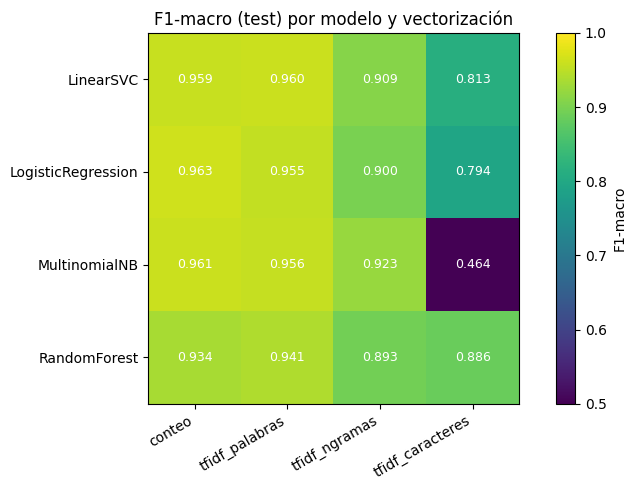

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import matplotlib.pyplot as plt
from google.colab import files
pivot = results_df.pivot(index="modelo", columns="vectorizacion", values="test_f1_macro")
pivot = pivot[["conteo", "tfidf_palabras", "tfidf_ngramas", "tfidf_caracteres"]]
#grafico pa comparar
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="viridis", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)
ax.set_title("F1-macro (test) por modelo y vectorización")
fig.colorbar(im, ax=ax, label="F1-macro")
plt.tight_layout()
plt.savefig("heatmap_f1_macro.png", dpi=150)
plt.show()
files.download("heatmap_f1_macro.png")

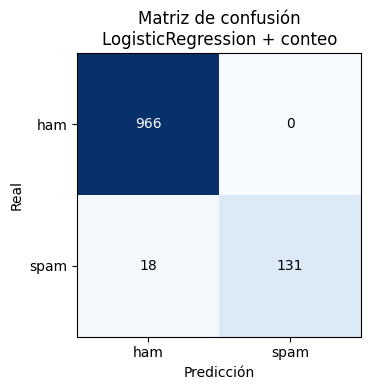

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
#matriz de confusion de la mejor combinacion
best_vec_name = best_row["vectorizacion"]
best_model_name = best_row["modelo"]
vectorizer = vectorizers[best_vec_name]
Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)
estimator, grid = model_grids[best_model_name]
estimator.set_params(**best_row["mejores_hiperparametros"])
estimator.fit(Xtr, y_train)
preds = estimator.predict(Xte)
cm = metrics.confusion_matrix(y_test, preds, labels=["ham", "spam"])

fig2, ax2 = plt.subplots(figsize=(4.5, 4))
im2 = ax2.imshow(cm, cmap="Blues")
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["ham", "spam"])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["ham", "spam"])
ax2.set_xlabel("Predicción"); ax2.set_ylabel("Real")
ax2.set_title(f"Matriz de confusión\n{best_model_name} + {best_vec_name}")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("matriz_confusion_mejor.png", dpi=150)
plt.show()
files.download("matriz_confusion_mejor.png")